<img src="images/arm_logo.png" width=250 alt="Project Pythia Logo"></img>

# Quantitative Precipitation Estimation Model
This notebook builds and trains a flexible MLP regression model for radar-based quantitative precipitation estimation. It introduces a reusable FlexMLP class with configurable activations and bundled defaults (Adam, MSE, ReduceLROnPlateau) for easy reuse. Training uses T-matrix estimated C‑band radar parameters from ARM ldquants product during Feb 01 2025 to Mar 06 2025 with early stopping. Validation and inference load the saved weights to predict on the VDISQuants dataset from Nov 20 2024 to Feb 08 2025, rescale targets, and compare against rain_rate. Because training spans only a few months, adding more historical data should improve heavy-rain performance.


## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Multilayer Perceptron](https://en.wikipedia.org/wiki/Linear_regression) | Necessary | Concept of the MLP and ANN |
| [Polarimetric Radar Data](https://training.weather.gov/nwstc/NEXRAD/RADAR/3-1.htm) | Necessary | KDP, ZDR, and Reflectvity factor |
| [Disdrometer Data](https://foundations.projectpythia.org/core/data-formats/netcdf-cf.html) | Helpful | Familiarity with DSD based estimation of radar parameters |

- **Time to learn**: 60 min.
- **System requirements**:
Use following `environment.yml` to create the environment for this notebook.

```yaml
name: torch_env
channels:
  - pytorch
  - conda-forge
dependencies:
  - python=3.10
  - pytorch
  - numpy
  - pandas
  - matplotlib
  - netcdf4
  - xarray
  - dask
  - h5netcdf
  - ipykernel
  - scikit-learn
```

`conda env create -f environment.yml`

# Building a Flexible MLP for Regression


Set up PyTorch, NumPy, data utilities, and netCDF reader.
import xarray as xr


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from netCDF4 import Dataset
import xarray as xr


## FlexMLP
Flexible MLP with internal activation resolution and built-in optimizer/loss/scheduler defaults (Adam + MSE + ReduceLROnPlateau). Provide activation as a class or a string such as 'ReLU'/'relu'.


In [ ]:
class FlexMLP(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dims,
        output_dim,
        activation_fn='relu',
        dropout=0.0,
        use_batchnorm=False,
        optimizer_name='adam',
        learning_rate=1e-3,
        loss_name='mseloss',
        scheduler_patience=2,
        scheduler_factor=0.5,
        device=None,
    ):
        super().__init__()
        self.device = device or self._detect_device()
        print(f'Using device: {self.device}')
        layers = []

        act_cls = self._resolve_activation(activation_fn)

        all_dims = [input_dim] + hidden_dims
        for i in range(len(hidden_dims)):
            layers.append(nn.Linear(all_dims[i], all_dims[i + 1]))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(all_dims[i + 1]))
            layers.append(act_cls())
            if dropout > 0.0:
                layers.append(nn.Dropout(p=dropout))

        layers.append(nn.Linear(hidden_dims[-1], output_dim))
        self.net = nn.Sequential(*layers).to(self.device)

        self.loss_fn = self._resolve_loss(loss_name)
        opt_cls = self._resolve_optimizer(optimizer_name)
        opt_kwargs = {'lr': learning_rate}
        if opt_cls is optim.SGD:
            opt_kwargs['momentum'] = 0.9
        self.optimizer = opt_cls(self.parameters(), **opt_kwargs)
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='min', patience=scheduler_patience, factor=scheduler_factor)

    def _detect_device(self):
        if torch.cuda.is_available():
            return torch.device('cuda')
        if torch.backends.mps.is_available():
            return torch.device('mps')
        return torch.device('cpu')

    def _resolve_activation(self, activation_fn):
        if isinstance(activation_fn, str):
            key = activation_fn.lower()
            mapping = {
                'relu': nn.ReLU,
                'tanh': nn.Tanh,
                'sigmoid': nn.Sigmoid,
                'leakyrelu': nn.LeakyReLU,
                'gelu': nn.GELU,
                'elu': nn.ELU,
                'selu': nn.SELU,
                'softplus': nn.Softplus,
            }
            if key not in mapping:
                raise ValueError('Unsupported activation: ' + activation_fn)
            return mapping[key]
        if issubclass(activation_fn, nn.Module):
            return activation_fn
        raise TypeError('activation_fn must be a string name or nn.Module class')

    def _resolve_optimizer(self, name):
        mapping = {
            'adam': optim.Adam,
            'adamw': optim.AdamW,
            'sgd': optim.SGD,
            'rmsprop': optim.RMSprop,
        }
        key = name.lower()
        if key not in mapping:
            raise ValueError('Unsupported optimizer: ' + name)
        return mapping[key]

    def _resolve_loss(self, name):
        mapping = {
            'mseloss': nn.MSELoss(),
            'mse': nn.MSELoss(),
            'maeloss': nn.L1Loss(),
            'mae': nn.L1Loss(),
            'huberloss': nn.HuberLoss(),
            'smoothl1loss': nn.SmoothL1Loss(),
        }
        key = name.lower()
        if key not in mapping:
            raise ValueError('Unsupported loss: ' + name)
        return mapping[key]

    def forward(self, x):
        return self.net(x)


### Load ldquants data
Read C-band radar variables, filter by Zh/ZDR/Kdp thresholds to avoid very low values, standardize, and build DataLoaders.


In [ ]:
from pathlib import Path

# Map dataset variable names to friendly short names
VARIABLES = {
    'reflectivity_factor_cband20c': 'zh',
    'differential_reflectivity_cband20c': 'zdr',
    'specific_differential_phase_cband20c': 'kdp',
    'specific_attenuation_cband20c': 'specific_attenuation',
    'gammapsd_shape': 'mu',
    'med_diameter': 'd0',
    'norm_num_concen': 'nw',
    'rain_rate': 'rainrate',
}

def load_dataset(data_dir):
    files = sorted(Path(data_dir).glob('*.nc'))
    if not files:
        raise FileNotFoundError('No .nc files found')
    ds = xr.open_mfdataset(files, combine='nested', concat_dim='time')
    return ds.rename(VARIABLES)

def filter_to_numpy(ds, input_features, target_features):
    ds = ds[input_features + target_features]
    mask = (ds['zh'] > 5.0) & (ds['zdr'] >= 0.0) & (ds['kdp'] >= 0.0)
    ds = ds.where(mask)
    df = ds.to_dataframe().dropna()
    if df.empty:
        raise ValueError('No valid samples after filtering.')
    X = df[input_features].to_numpy().astype('float32')
    Y = df[target_features].to_numpy().astype('float32')
    return X, Y

def split_scale_to_loaders(X, Y, train_ratio=0.8, batch_size=16, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(X))
    split = max(1, int(len(X) * train_ratio))
    split = min(split, len(X) - 1)
    train_idx, val_idx = idx[:split], idx[split:]

    X_train, X_val = X[train_idx], X[val_idx]
    Y_train, Y_val = Y[train_idx], Y[val_idx]

    mean_X, std_X = X_train.mean(axis=0), X_train.std(axis=0); std_X[std_X == 0] = 1
    mean_Y, std_Y = Y_train.mean(axis=0), Y_train.std(axis=0); std_Y[std_Y == 0] = 1
    X_train = (X_train - mean_X) / std_X
    X_val = (X_val - mean_X) / std_X
    Y_train = (Y_train - mean_Y) / std_Y
    Y_val = (Y_val - mean_Y) / std_Y

    train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(Y_train))
    val_ds = TensorDataset(torch.tensor(X_val), torch.tensor(Y_val))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, (mean_Y, std_Y)

def load_ldquants(data_dir, input_features, target_features, train_ratio=0.8, batch_size=16, seed=42):
    ds = load_dataset(data_dir)
    X, Y = filter_to_numpy(ds, input_features, target_features)
    return split_scale_to_loaders(X, Y, train_ratio=train_ratio, batch_size=batch_size, seed=seed)

DATA_DIR = '/Users/bhupendra/projects/bnf-amf3/data/bnfldquantsM1.c1'
INPUT_FEATURES = ['zh', 'zdr', 'kdp', 'specific_attenuation']
TARGET_FEATURES = ['rainrate']

train_loader, val_loader, target_scaler = load_ldquants(DATA_DIR, INPUT_FEATURES, TARGET_FEATURES, batch_size=16)


### Instantiate model for ldquants
Build the MLP and initialize its optimizer/loss/scheduler using default names.


In [ ]:
model = FlexMLP(
    input_dim=len(INPUT_FEATURES),
    hidden_dims=[256, 128, 64, 32],
    output_dim=len(TARGET_FEATURES),
    activation_fn='relu',
    dropout=0.2,
    use_batchnorm=True,
    optimizer_name='adam',
    learning_rate=1e-3,
    loss_name='mseloss',
    scheduler_patience=2,
    scheduler_factor=0.5,
    device=None,
)
device = model._detect_device()  # optional: device variable if needed elsewhere


Using device: mps


### Train and validate
Run epochs with early stopping, using the model-owned optimizer/loss/scheduler.


In [ ]:
epochs = 50
best_val_loss = np.inf
patience = 5
patience_counter = 0

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(model.device), y_batch.to(model.device)

        preds = model(X_batch)
        loss = model.loss_fn(preds, y_batch)

        model.optimizer.zero_grad()
        loss.backward()
        model.optimizer.step()

        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(model.device), y_val.to(model.device)
            val_preds = model(X_val)
            val_loss += model.loss_fn(val_preds, y_val).item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    model.scheduler.step(avg_val_loss)

    print(f'Epoch {epoch + 1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print('Early stopping triggered.')
            break




Epoch 01 | Train Loss: 0.4880 | Val Loss: 1.4439
Epoch 02 | Train Loss: 0.3501 | Val Loss: 0.1299
Epoch 03 | Train Loss: 0.2805 | Val Loss: 0.1436
Epoch 04 | Train Loss: 0.2441 | Val Loss: 0.1181
Epoch 05 | Train Loss: 0.2341 | Val Loss: 0.9753
Epoch 06 | Train Loss: 0.2325 | Val Loss: 0.3878
Epoch 07 | Train Loss: 0.2040 | Val Loss: 0.1040
Epoch 08 | Train Loss: 0.1712 | Val Loss: 0.1469
Epoch 09 | Train Loss: 0.1551 | Val Loss: 0.1380
Epoch 10 | Train Loss: 0.1420 | Val Loss: 0.5140
Epoch 11 | Train Loss: 0.1150 | Val Loss: 0.1221
Epoch 12 | Train Loss: 0.1186 | Val Loss: 0.2025
Early stopping triggered.



## Saving only the model weights
We store just the `state_dict` (`mlp_radar_qpe_weights.pt`) instead of the full object. This avoids unpickling issues across PyTorch versions and devices; later we recreate the model and load these weights for inference.


In [ ]:
# Save final model weights
torch.save(model.state_dict(), 'mlp_radar_qpe_weights.pt')

## Predict on VDISQuants data using saved model
Load the trained weights, run inference on the VDISQuants dataset, and invert the target scaling.


Using device: mps
MAE: 0.421 | RMSE: 1.443 | R^2: 0.940


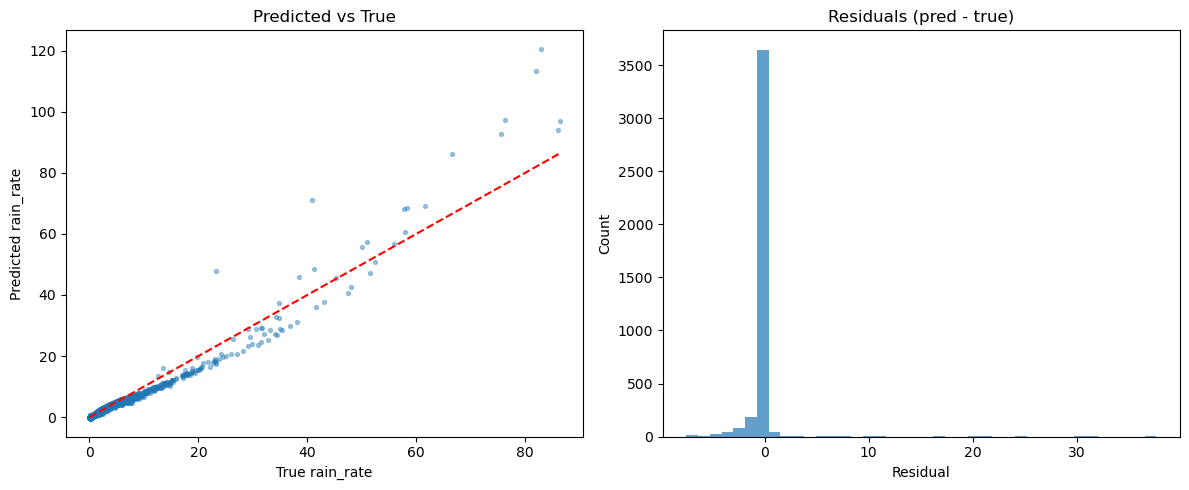

In [24]:
VDIS_DIR = '/Users/bhupendra/projects/bnf-amf3/data/bnfvdisquantsM1.c1'
infer_device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

# Build VDIS loaders (reuse existing loader & filters)
vdis_loader, _, vdis_target_scaler = load_ldquants(
    VDIS_DIR, INPUT_FEATURES, TARGET_FEATURES, batch_size=16, seed=42
)

# Recreate model skeleton and load saved weights
model = FlexMLP(
    input_dim=len(INPUT_FEATURES),
    hidden_dims=[256, 128, 64, 32],
    output_dim=len(TARGET_FEATURES),
    activation_fn='relu',
    dropout=0.2,
    use_batchnorm=True,
    optimizer_name='adam',
    learning_rate=1e-3,
    loss_name='mseloss',
    scheduler_patience=2,
    scheduler_factor=0.5,
    device=infer_device,
)
state = torch.load('mlp_radar_qpe_weights.pt', map_location=infer_device)
model.load_state_dict(state)
model.to(infer_device)
model.eval()

preds = []
targets = []
with torch.no_grad():
    for xb, yb in vdis_loader:
        xb = xb.to(infer_device)
        out = model(xb)
        preds.append(out.cpu())
        targets.append(yb)

preds = torch.cat(preds, dim=0).numpy()
targets = torch.cat(targets, dim=0).numpy()
mean_Y, std_Y = vdis_target_scaler
preds_unscaled = preds * std_Y + mean_Y
targets_unscaled = targets * std_Y + mean_Y

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(targets_unscaled, preds_unscaled)
rmse = mean_squared_error(targets_unscaled, preds_unscaled) ** 0.5
r2 = r2_score(targets_unscaled, preds_unscaled)
print(f"MAE: {mae:.3f} | RMSE: {rmse:.3f} | R^2: {r2:.3f}")

# Visuals
import pandas as pd
import matplotlib.pyplot as plt
pred_df = pd.DataFrame({
    'pred_rainrate': preds_unscaled.flatten(),
    'true_rainrate': targets_unscaled.flatten(),
})

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(pred_df['true_rainrate'], pred_df['pred_rainrate'], s=8, alpha=0.4)
ax[0].plot([pred_df['true_rainrate'].min(), pred_df['true_rainrate'].max()],
          [pred_df['true_rainrate'].min(), pred_df['true_rainrate'].max()], 'r--')
ax[0].set_xlabel('True rain_rate')
ax[0].set_ylabel('Predicted rain_rate')
ax[0].set_title('Predicted vs True')

residuals = pred_df['pred_rainrate'] - pred_df['true_rainrate']
ax[1].hist(residuals, bins=40, alpha=0.7)
ax[1].set_title('Residuals (pred - true)')
ax[1].set_xlabel('Residual')
ax[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

Note: This notebook trained on only a couple of months of data. With more historical files, the model should generalize better and improve prediction quality for heavy rainfall.